<a href="https://colab.research.google.com/github/Jhoniisjelly/Data201_JhonathanUrquilla/blob/main/project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data 201 Project 2
## Spring 2026
##### Jhonathan Urquilla

The dataset I am using comes from the OpenIntro CPU dataset available through OpenIntro Data. It includes technical specifications for different CPU models from manufacturers such as Intel and AMD. The data contains information like number of cores, threads, base clock speed, manufacturing process, and thermal design power (TDP).

The population of interest is all consumer and commercial CPUs released across different generations. Each row in the dataset represents a single CPU model and its specifications. The data was collected from publicly available CPU specification sources and manufacturer documentation.

One limitation of this dataset is that it does not include real-world performance measures like benchmark or gaming results, so it only reflects hardware specifications and not actual performance. There may also be some imbalance in the data since certain manufacturers and CPU types appear more often than others.

Citation:
“CPU Dataset,” OpenIntro, https://www.openintro.org/data/index.php?data=cpu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.formula.api as smf
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve, mean_squared_error, r2_score

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/cpu.csv", encoding="latin1")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
df.head()

,company,name,codename,cores,threads,base_clock,boost_clock,socket,process,l3_cache,tdp,released
0,Intel,Pentium E5500,Wolfdale,2,2,2.800,NaN,775,45,NaN,65,2010-04-18
1,Intel,Pentium E6700,Wolfdale,2,2,3.200,NaN,775,45,NaN,65,2010-05-30
2,Intel,Pentium E5700,Wolfdale,2,2,3.000,NaN,775,45,NaN,65,2010-08-08
3,Intel,Celeron E3500,Wolfdale,2,2,2.700,NaN,775,45,NaN,65,2010-08-29
4,Intel,Pentium E6800,Wolfdale,2,2,3.333,NaN,775,45,NaN,65,2010-08-29


| Column     | Description                                    | Data Type    |
| ---------- | ---------------------------------------------- | ------------ |
| company    | Manufacturer of the CPU                        | Categorical  |
| name       | Name of the CPU model                          | Categorical  |
| codename   | Code name of the CPU model                     | Categorical  |
| cores      | Number of cores in the CPU                     | Quantitative |
| threads    | Number of threads supported by the CPU         | Quantitative |
| base_clock | Base clock speed of the CPU in GHz             | Quantitative |
| socket     | Socket type for the CPU                        | Categorical  |
| process    | Manufacturing process of the CPU in nm         | Quantitative |
| tdp        | Thermal Design Power (TDP) of the CPU in watts | Quantitative |
| released   | Release year of the CPU                        | Quantitative |


In [3]:
print(df.columns)

print(df.shape)

cpu_nan = df.isna().sum()

print(cpu_nan)

Index(['company', 'name', 'codename', 'cores', 'threads', 'base_clock',
       'boost_clock', 'socket', 'process', 'l3_cache', 'tdp', 'released'],
      dtype='object')
(875, 12)
company          0
name             0
codename         0
cores            0
threads          0
base_clock       0
boost_clock    318
socket           0
process          0
l3_cache       185
tdp              0
released         2
dtype: int64


In [4]:
df = df.drop(columns=['boost_clock', 'l3_cache'])

df = df.dropna()

cpu_nan = df.isna().sum()

print(df.shape)
print(cpu_nan)

(873, 10)
company       0
name          0
codename      0
cores         0
threads       0
base_clock    0
socket        0
process       0
tdp           0
released      0
dtype: int64


After filtering the data by dropping the coulumns boost_clock, l3_cache as well as data containing NA's the data set has a total of 873 rows with 10 variables. The reason I dropped boost_clock and l3_cache is so I had more data to work with opposed getting rid of 300+ rows worth of data.

# Data Analysis and Modeling

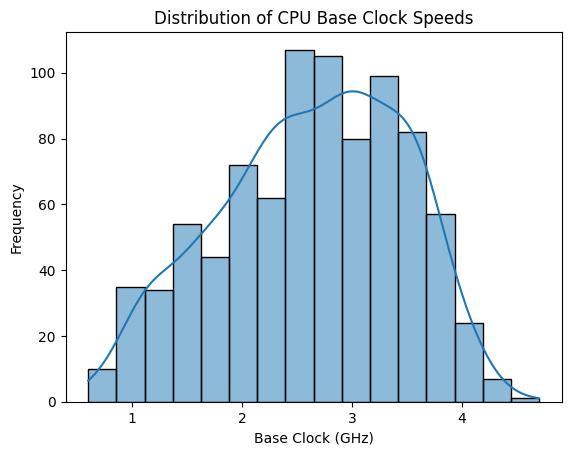

In [5]:
sns.histplot(df['base_clock'], kde=True)
plt.xlabel('Base Clock (GHz)')
plt.ylabel('Frequency')
plt.title('Distribution of CPU Base Clock Speeds')
plt.show()

This plot shows a skewed distribution. Most CPUs in the dataset seem to have a base clock speed between 3.0 and 4.0 GHz, with fewer CPUs having much lower or higher clock speeds. This is actually typical of consumer grade processors where clock speeds generally do range within a particular range for efficiency and performance balance.

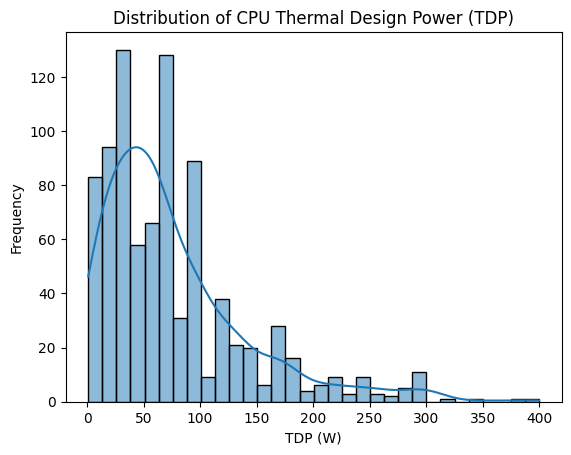

In [6]:
sns.histplot(df['tdp'], kde=True)
plt.xlabel('TDP (W)')
plt.ylabel('Frequency')
plt.title('Distribution of CPU Thermal Design Power (TDP)')
plt.show()

From this plot, we can observe that most CPUs in the dataset have a TDP range that is between 35W to 95W, which is also usually typical for consumer processors around this time period. CPUs with higher TDPs (e.g., above 100W) are more specialized for higher performing devices.

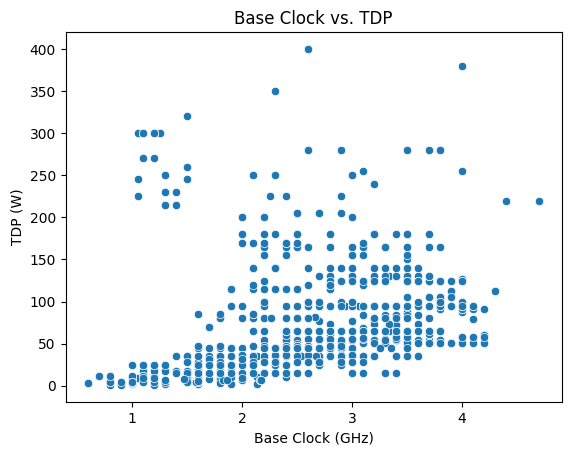

In [7]:
sns.scatterplot(x='base_clock', y='tdp', data=df)
plt.xlabel('Base Clock (GHz)')
plt.ylabel('TDP (W)')
plt.title('Base Clock vs. TDP')
plt.show()

From the scatter plot, it is fairly evident that there isn't a strong linear correlation between base clock and TDP. Although, there are some CPUs with high clock speeds as well as high TDP, this isn't universally true. TDP usually depends on other factors like the number of cores the cpu has or even process used for manufacturing.

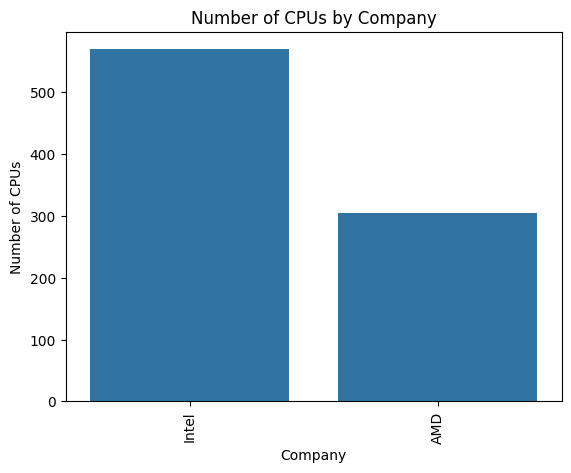

In [8]:
sns.countplot(x='company', data=df)
plt.xlabel('Company')
plt.ylabel('Number of CPUs')
plt.title('Number of CPUs by Company')
plt.xticks(rotation=90)
plt.show()

The bar chart shows the number of CPUs available from each of the companies. Intel for example has a much larger representation in the dataset compared to AMD CPU's. This would indicate a higher market share, demand, or more variety of processors from Intel in the dataset.

# b. Train/Test Split

In [9]:
df["high_tdp"] = (df["tdp"] > df["tdp"].median()).astype(int)

df = df.dropna()

X = df[['cores', 'threads', 'base_clock', 'socket', 'process']]
X = pd.get_dummies(X, drop_first=True)
y = df['high_tdp']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

Training data shape: (698, 63)
Test data shape: (175, 63)


I went with a 80/20 split to make sure that the model has sufficient amount of data to learn from (80%) while leaving enough unseen data (20%) to be able to check how well it performs.

In [21]:
model = smf.logit("high_tdp ~ cores + threads + base_clock", data=df).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.306279
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:               high_tdp   No. Observations:                  873
Model:                          Logit   Df Residuals:                      869
Method:                           MLE   Df Model:                            3
Date:                Fri, 01 May 2026   Pseudo R-squ.:                  0.5352
Time:                        02:21:37   Log-Likelihood:                -267.38
converged:                       True   LL-Null:                       -575.26
Covariance Type:            nonrobust   LLR p-value:                3.856e-133
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -9.0562      0.729    -12.431      0.000     -10.484      -7.628
cores          0.7887      0

The baseline model uses core count, thread count, and base clock speed to help predict whether a CPU has high power consumption. These features were selected as they usually directly relate to the processing performance.

In [22]:
model2 = smf.logit(
    "high_tdp ~ cores + threads + base_clock + C(process)",
    data=df
).fit()

print(model2.summary())

         Current function value: 0.210247
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:               high_tdp   No. Observations:                  873
Model:                          Logit   Df Residuals:                      861
Method:                           MLE   Df Model:                           11
Date:                Fri, 01 May 2026   Pseudo R-squ.:                  0.6809
Time:                        02:23:09   Log-Likelihood:                -183.55
converged:                      False   LL-Null:                       -575.26
Covariance Type:            nonrobust   LLR p-value:                6.824e-161
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          -19.2066      1.726    -11.126      0.000     -22.590     -15.823
C(process)[T.10]    -9.9010   4925.941     -0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


The improved model adds the manufacturing process size as a categorical variable. This was added in because smaller manufacturing process nodes used inproduction are generally more efficient and may significantly affect power consumption.

In [24]:
y_true = df["high_tdp"]

y_pred1 = model.predict(df)
rmse1 = np.sqrt(mean_squared_error(y_true, y_pred1))
r1 = r2_score(y_true, y_pred1)

y_pred2 = model2.predict(df)
rmse2 = np.sqrt(mean_squared_error(y_true, y_pred2))
r2 = r2_score(y_true, y_pred2)

print("Baseline RMSE:", rmse1)
print("Baseline R^2:", r1)

print("Improved RMSE:", rmse2)
print("Improved R^2:", r2)

Baseline RMSE: 0.31585724165985213
Baseline R^2: 0.5719988337469047
Improved RMSE: 0.2541694489937947
Improved R^2: 0.7228531349337796


The improved model performs better than the baseline model. This can be shown by its lower RMSE of 0.2542 compared to 0.3159 for the baseline model, and its higher R² value of 0.7229 compared to 0.5720. The decrease in RMSE does indicate that the improved model's predictions are more accurate and closer to the actual values on average. The increase in R² shows that the model is able to explain about 72.3% of the variation in CPU TDP classification, compared to about 57.2% in the baseline model. Overall, the improved model provides a way better fit to the data and makes more reliable predictions, although there is still some variation in the data that the model does not capture, suggesting that additional factors could also influence CPU power consumption.

# f. Interpret Your Final Model

In the final model, the most important variables are cores, base clock speed, and manufacturing process. These variables all have a significant relationship with whether a CPU is classified as high or low TDP. In general, CPUs with more cores and higher clock speeds are more likely to have higher power consumption. The manufacturing process also affects the results, since different process sizes relate to different levels of efficiency. Overall, the model shows that both performance and design features influence CPU power usage.

# g. Predictions

In [27]:
new_data = pd.DataFrame({
    "cores": [4, 8, 16],
    "threads": [8, 16, 32],
    "base_clock": [2.8, 3.6, 4.2],
    "process": [14, 22, 7]
})

predictions = model2.predict(new_data)
print("New data points Predictions ")

for i, prob in enumerate(predictions):
    print(f"Data Point {i+1}: {prob:.3f}")

New data points Predictions 
Data Point 1: 0.019
Data Point 2: 0.997
Data Point 3: 1.000


The predictions show clear separation between the CPU examples. Data Point 1 has a very low probability (0.019), meaning it is unlikely to be high TDP. Data Points 2 and 3 have very high probabilities (0.997 and 1.000), meaning they are very likely to be high TDP. Overall, the results make sense because higher performance CPUs tend to require more power to operate.

# Conclusions and Recommendations

Overall, this project shows that CPU specifications such as cores, base clock speed, and manufacturing process are useful in being able to predict whether a CPU has high or low TDP. The improved model performed better than the baseline model, with a lower error rate and higher explanatory power, meaning it captures more of the patterns in the data.

However, the model still does not explain all of the variation in CPU power usage, which could suggest that other factors not included in the dataset also play a role. This could include CPU architecture design, efficiency improvements between generations, or real-world workload performance.

For future improvements, adding more detailed features such as CPU architecture type, cache size, or benchmark performance scores could help improve accuracy. I think it would be very interesting to also include more recent models to see if theres a larger spread as the newest model is in 2020. Overall, the model provides useful insights into CPU power consumption, it could be strengthened further with more complete and performance based data.